## Notebook Structure

This research notebook is organized as:

1. Problem
2. Methodology
3. Visuals
4. Results
5. Insight
6. Business Value

# Financial Asset Return Analysis
**Author:** *Solomon Dejenie* <br>
**Role:** *Data Analyst | Econometrics*  <br>
**Focus:** Statistical Analysis of Asset Returns <br>
**Tools:** *Python, Pandas, NumPy, Matplotlib*


###### *This Project is about Statistical Risk and Return Characteristics*
---
## Objective
Analyze statistical properties of financial asset returns.
# Problem

Financial returns often violate normality assumptions,
creating challenges for risk estimation.

This project investigates:

- Distribution behavior
- Tail risk
- Volatility dynamics
- Drawdowns

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf

# Methodology

Applied techniques:

- Log Return Analysis
- Distribution Diagnostics
- Rolling Volatility
- Value at Risk
- Drawdown Analytics

In [11]:
prices=yf.download(
'SPY',
start='2015-01-01'
)['Close']

returns=np.log(
prices/prices.shift(1)
).dropna()

[*********************100%***********************]  1 of 1 completed


# Visuals

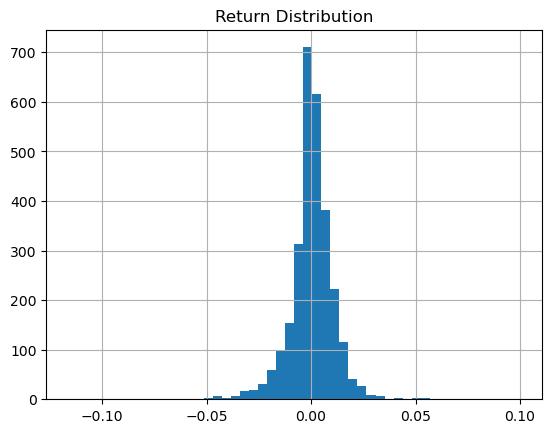

In [12]:

import matplotlib.pyplot as plt

returns.hist(bins=50)

plt.title('Return Distribution')

# Save the figure
plt.savefig("return_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

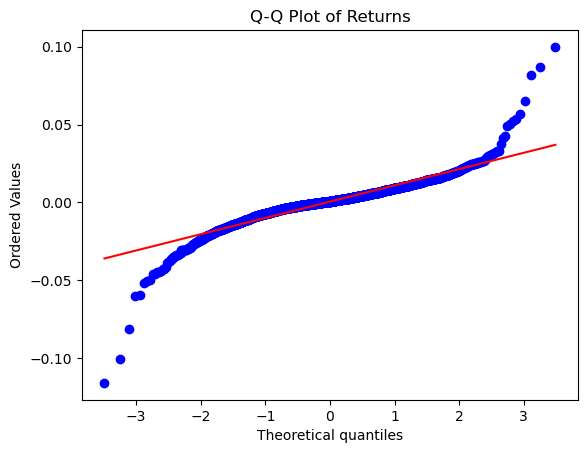

In [13]:
import matplotlib.pyplot as plt
import scipy.stats as stats

stats.probplot(
    returns.squeeze(),
    dist='norm',
    plot=plt
)

plt.title('Q-Q Plot of Returns')

# Save figure
plt.savefig("qq_plot_returns.png", dpi=300, bbox_inches='tight')

plt.show()

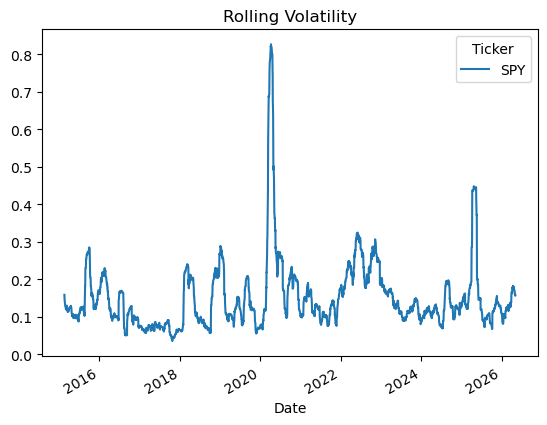

In [14]:
import matplotlib.pyplot as plt
import numpy as np

rolling_vol = (
    returns.rolling(30).std() * np.sqrt(252)
)

rolling_vol.plot()

plt.title('Rolling Volatility')

# Save image
plt.savefig("rolling_volatility.png", dpi=300, bbox_inches='tight')

plt.show()

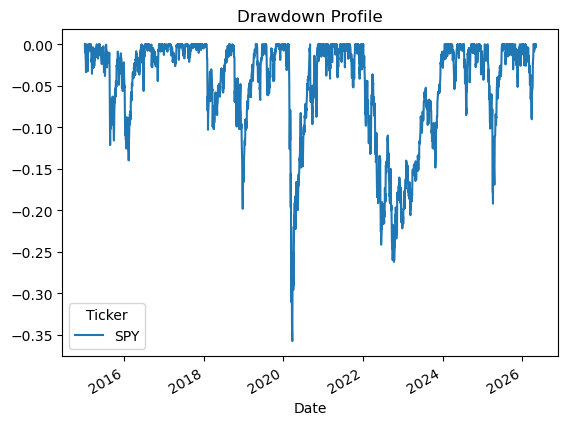

In [15]:
import matplotlib.pyplot as plt

wealth = (1 + returns).cumprod()
peak = wealth.cummax()
drawdown = (wealth - peak) / peak

drawdown.plot()

plt.title('Drawdown Profile')

# Save figure
plt.savefig("drawdown_profile.png", dpi=300, bbox_inches='tight')

plt.show()

# Results

In [16]:
import numpy as np
import pandas as pd

# -----------------------------
# Risk Metrics
# -----------------------------
var95 = np.percentile(returns, 5)

summary = pd.DataFrame({
    "Metric": [
        "Volatility",
        "Skewness",
        "Kurtosis",
        "VaR (5%)",
        "Max Drawdown"
    ],
    "Value": [
        returns.std().mean(),
        returns.skew().mean(),
        returns.kurtosis().mean(),
        var95,
        drawdown.min().min()
    ]
})

# -----------------------------
# SAVE RETURNS DATA
# -----------------------------
returns.to_csv(
    "tables/returns_data.csv",
    index_label="Date"
)

# -----------------------------
# SAVE RISK SUMMARY
# -----------------------------
summary.to_csv(
    "tables/risk_summary.csv",
    index=False
)

# -----------------------------
# DISPLAY SUMMARY
# -----------------------------
summary


,Metric,Value
0,Volatility,0.011167
1,Skewness,-0.575263
2,Kurtosis,14.489226
3,VaR (5%),-0.016828
4,Max Drawdown,-0.357459


# Insight

Empirical findings suggest:

- Non-normal return behavior
- Fat-tail risk exposure
- Volatility clustering persistence
- Material downside drawdown risk

Traditional Gaussian assumptions may understate risk.

# Business Value

Applications:

- Market Risk Analytics
- Stress Testing
- Portfolio Risk Management
- Asset Selection
- Downside Risk Assessment

Findings support practical risk management decisions.

# Conclusion

This project demonstrates applied quantitative finance research
through reproducible modeling, empirical evidence, and business interpretation.